In [8]:
import pandas as pd

original_df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
encoded_data = pd.read_csv("../data/proccessed/finish-unsupervised.csv")
encoded_data['Churn'] = original_df['Churn'].map({'Yes': 1, 'No': 0})
encoded_data.to_csv('../data/proccessed/telco_prepared_for_supervised.csv', index=False)


Accuracy: 0.7991

              precision    recall  f1-score   support

No Churn (0)       0.84      0.90      0.87      1035
   Churn (1)       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



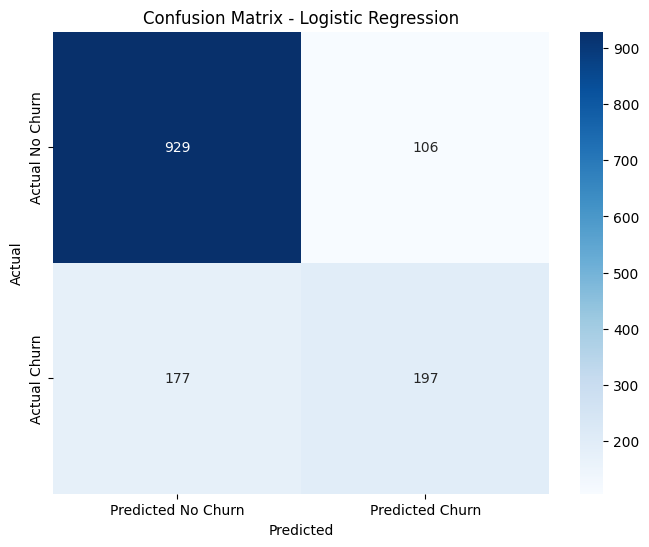

ROC-AUC Score: 0.8431



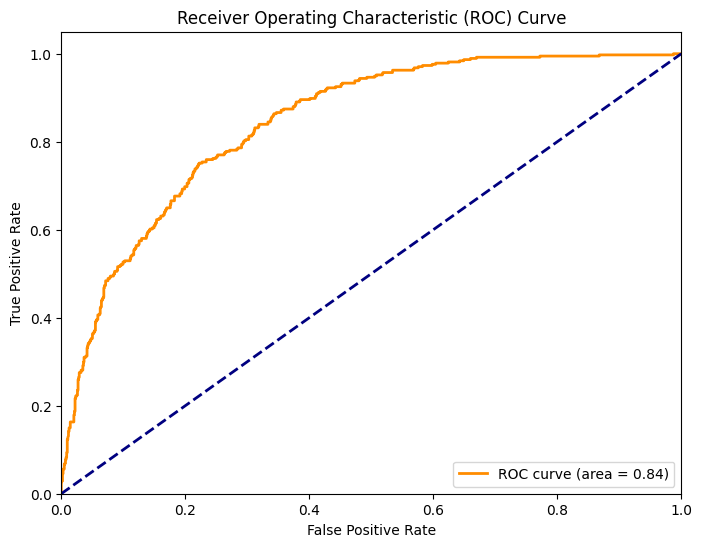

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    roc_auc_score,
    roc_curve
)

df = pd.read_csv('../data/proccessed/telco_prepared_for_supervised.csv')

df = df.drop(columns=['Unnamed: 0'], errors='ignore')

if 'customerID' in df.columns:
    X = df.drop(['Churn', 'customerID'], axis=1)
    
else:
    X = df.drop('Churn', axis=1)
    
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted No Churn', 'Predicted Churn'], 
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc:.4f}\n")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
